<a href="https://colab.research.google.com/github/pondpatipatpankaew/Code-Geo/blob/main/Lab/Lab_2_%E0%B8%9B%E0%B8%8F%E0%B8%B4%E0%B8%9E%E0%B8%B1%E0%B8%92%E0%B8%99%E0%B9%8C_6606520168.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **1. INSTALL & IMPORT**

In [64]:
!pip install geopandas rasterio folium geemap earthengine-api shapely pyproj fiona rtree -q

import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.plot import plotting_extent
import matplotlib.pyplot as plt
import numpy as np
import folium
import ee
import geemap
from google.colab import drive

## **2. CONNECT GOOGLE DRIVE**

In [65]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **3. LOAD VECTOR DATA**

In [66]:
# --- 3.1 Load Province Boundary ---
shp_path = '/content/drive/MyDrive/Labdata/Lab Data/lopburi.shp'
lopburi = gpd.read_file(shp_path)

print("Vector CRS:", lopburi.crs)
print("Number of features:", len(lopburi))


# --- 3.2 Load Weather Stations ---
station_path = '/content/drive/MyDrive/Labdata/Lab Data/TMD_ALL_Stations.shp'
stations = gpd.read_file(station_path)

stations = stations.to_crs(lopburi.crs)

stations_lopburi = gpd.sjoin(stations, lopburi, predicate="within")

Vector CRS: EPSG:4326
Number of features: 1


## **4. VISUALIZE VECTOR DATA**

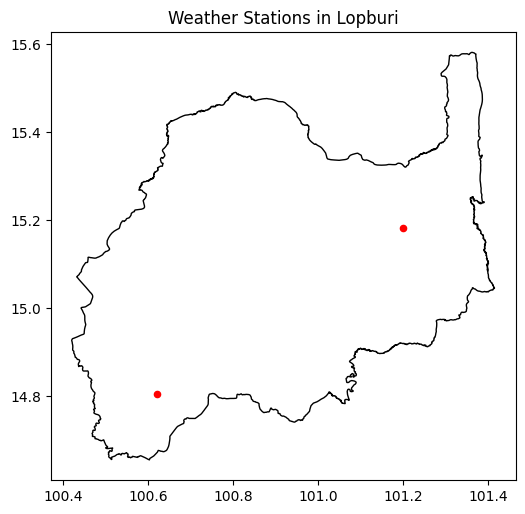

In [67]:
fig, ax = plt.subplots(figsize=(6,6))
lopburi.plot(ax=ax, edgecolor='black', facecolor='none')
stations_lopburi.plot(ax=ax, color='red', markersize=20)
plt.title("Weather Stations in Lopburi")
plt.show()

In [77]:
center = lopburi.geometry.centroid.iloc[0]

m = folium.Map(location=[center.y, center.x], zoom_start=8)

folium.GeoJson(lopburi).add_to(m)

for _, row in stations_lopburi.iterrows():
    folium.Marker(
        location=[row.geometry.y, row.geometry.x]
    ).add_to(m)

m

/tmp/ipython-input-4280195466.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center = lopburi.geometry.centroid.iloc[0]


## **5. LOAD RASTER DATA**

In [68]:
raster_path = '/content/drive/MyDrive/Labdata/Lab Data/Lopburi.tif'
src = rasterio.open(raster_path)

print("CRS:", src.crs)
print("Resolution:", src.res)
print("Width x Height:", src.width, "x", src.height)
print("Number of Bands:", src.count)

CRS: EPSG:4326
Resolution: (0.0006180181576575864, 0.0005961566358528606)
Width x Height: 2481 x 2501
Number of Bands: 12


## **6. TRUE COLOR COMPOSITE**

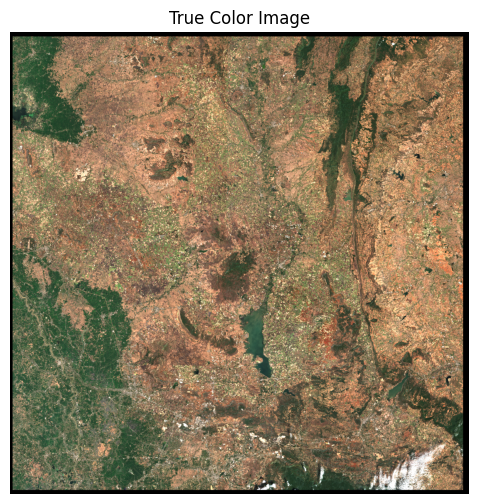

In [69]:
red = src.read(4)
green = src.read(3)
blue = src.read(2)

rgb = np.dstack((red, green, blue)).astype(float)

p2, p98 = np.percentile(rgb, (2, 98))
rgb_stretch = np.clip((rgb - p2) / (p98 - p2), 0, 1)

plt.figure(figsize=(6,6))
plt.imshow(rgb_stretch)
plt.title("True Color Image")
plt.axis("off")
plt.show()

## **7. CLIP RASTER TO PROVINCE**

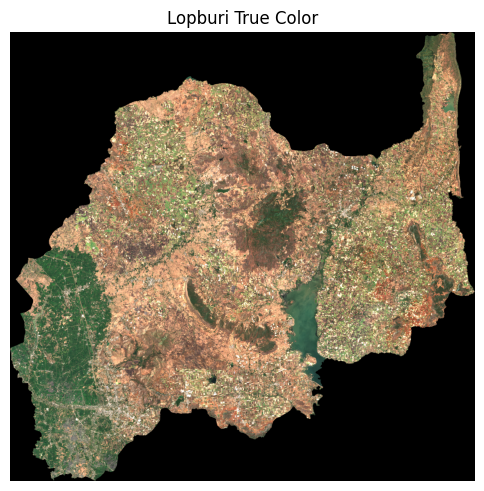

In [70]:
lopburi_geom = lopburi.geometry.values

clipped_img, clipped_transform = mask(src, lopburi_geom, crop=True)

# Show clipped true color
red = clipped_img[3].astype(float)
green = clipped_img[2].astype(float)
blue = clipped_img[1].astype(float)

rgb = np.dstack((red, green, blue))
p2, p98 = np.percentile(rgb, (2, 98))
rgb_stretch = np.clip((rgb - p2) / (p98 - p2), 0, 1)

plt.figure(figsize=(6,6))
plt.imshow(rgb_stretch)
plt.title("Lopburi True Color")
plt.axis("off")
plt.show()

## **8. CALCULATE NDVI**

/tmp/ipython-input-1435389711.py:7: RuntimeWarning: invalid value encountered in divide
  (nir - red) / (nir + red)


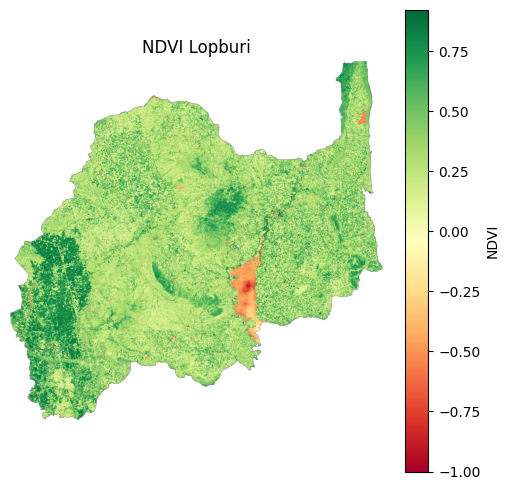

In [71]:
nir = clipped_img[7].astype(float)
red = clipped_img[3].astype(float)

ndvi = np.where(
    (nir + red) == 0,
    np.nan,
    (nir - red) / (nir + red)
)

plt.figure(figsize=(6,6))
plt.imshow(ndvi, cmap='RdYlGn')
plt.colorbar(label="NDVI")
plt.title("NDVI Lopburi")
plt.axis("off")
plt.show()

## **9. OVERLAY NDVI + STATIONS**

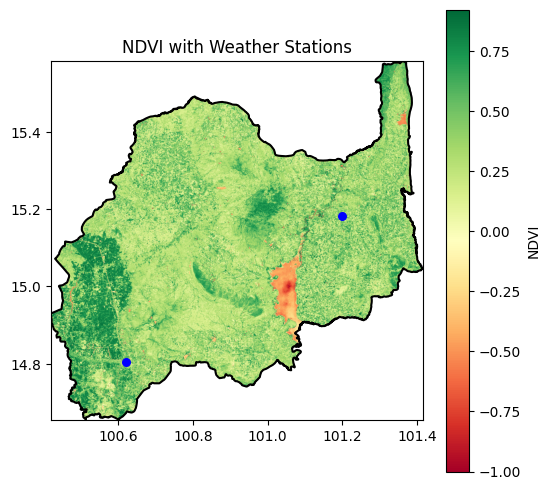

In [72]:
extent = plotting_extent(ndvi, clipped_transform)

fig, ax = plt.subplots(figsize=(6,6))

ndvi_plot = ax.imshow(ndvi, cmap='RdYlGn', extent=extent)
lopburi.boundary.plot(ax=ax, color='black')
stations_lopburi.plot(ax=ax, color='blue', markersize=30)

plt.colorbar(ndvi_plot, ax=ax, label="NDVI")
plt.title("NDVI with Weather Stations")
plt.show()

## **10. EXTRACT NDVI AT STATIONS**

In [73]:
import rasterio

ndvi_values = []

for idx, row in stations_lopburi.iterrows():
    x, y = row.geometry.x, row.geometry.y
    r, c = rasterio.transform.rowcol(clipped_transform, x, y)

    if 0 <= r < ndvi.shape[0] and 0 <= c < ndvi.shape[1]:
        ndvi_values.append(ndvi[r, c])
    else:
        ndvi_values.append(np.nan)

stations_lopburi["NDVI"] = ndvi_values

## **11. STATISTICAL ANALYSIS**

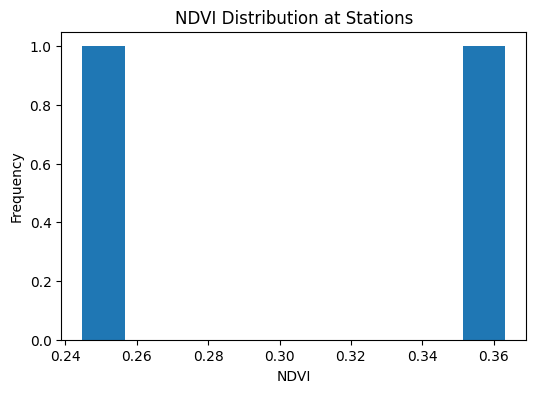

,count
NDVI_Class,
Moderate Vegetation,2


In [74]:
# Histogram
plt.figure(figsize=(6,4))
plt.hist(stations_lopburi["NDVI"].dropna(), bins=10)
plt.title("NDVI Distribution at Stations")
plt.xlabel("NDVI")
plt.ylabel("Frequency")
plt.show()


# Classification
def classify_ndvi(value):
    if value < 0:
        return "Water/Built-up"
    elif value < 0.2:
        return "Low Vegetation"
    elif value < 0.5:
        return "Moderate Vegetation"
    else:
        return "High Vegetation"

stations_lopburi["NDVI_Class"] = stations_lopburi["NDVI"].apply(classify_ndvi)

stations_lopburi["NDVI_Class"].value_counts()

## **12. FINAL THEMATIC MAP**

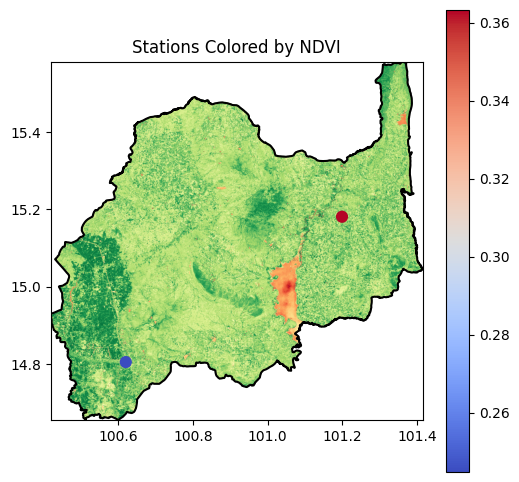

In [75]:
fig, ax = plt.subplots(figsize=(6,6))

ndvi_plot = ax.imshow(ndvi, cmap='RdYlGn', extent=extent)
lopburi.boundary.plot(ax=ax, color='black')

stations_lopburi.plot(
    ax=ax,
    column="NDVI",
    cmap="coolwarm",
    legend=True,
    markersize=60
)

plt.title("Stations Colored by NDVI")
plt.show()

## **คำถามท้าย Lab**

# **1. ข้อดีและข้อเสียของการใช้ Matplotlib และ Folium ในการแสดงผลข้อมูลเชิงพื้นที่คืออะไร?**
**Matplotlib**
ข้อดี : เหมาะกับการวิเคราะห์เชิงสถิติ ควบคุมรูปแบบกราฟได้ละเอียด แสดง raster ได้ดี

ข้อเสีย : ไม่เป็น Interactive ซูม/คลิกดูข้อมูลไม่ได้

**Folium**
ข้อดี : เป็น Interactive เหมาะกับการนำเสนอแผนที่

ข้อเสีย : วิเคราะห์เชิงลึกยาก และจัดการ raster ขนาดใหญ่ไม่สะดวก

# **2. ทำไมเราต้องใช้ Masking และ Clipping ในการวิเคราะห์ข้อมูลภาพถ่ายดาวเทียม?**
เพื่อจำกัดข้อมูลให้อยู่เฉพาะพื้นที่ศึกษา ช่วยลดขนาดข้อมูล เพิ่มความแม่นยำ และป้องกันผลกระทบจากข้อมูลนอกพื้นที่ที่สนใจ

# **3. ค่า NDVI บ่งบอกถึงอะไร? และสามารถใช้ NDVI ในการวิเคราะห์อะไรได้บ้าง?**
NDVI ใช้วัดความหนาแน่นและสุขภาพของพืชพรรณ
สามารถใช้วิเคราะห์สุขภาพพืช ปริมาณพื้นที่สีเขียว การเปลี่ยนแปลงป่าไม้ และภัยแล้ง

## **4. การแปลงค่าพิกัด (CRS) มีความสำคัญอย่างไรในการทำงานกับข้อมูลเวกเตอร์และแรสเตอร์?**
CRS ต้องตรงกันเพื่อให้ข้อมูลเวกเตอร์และแรสเตอร์ซ้อนทับกันได้อย่างถูกต้อง หากไม่ตรงกันจะทำให้ตำแหน่งผิดพลาดและวิเคราะห์คลาดเคลื่อน

## **5. หากต้องการวิเคราะห์ข้อมูลภาพถ่ายดาวเทียมในช่วงเวลาต่าง ๆ (Time Series) ควรทำอย่างไร?**
ใช้ภาพหลายช่วงเวลา คำนวณดัชนี เช่น NDVI ในแต่ละช่วง แล้วเปรียบเทียบแนวโน้มการเปลี่ยนแปลงตามเวลา